---
title: Introduction to EDA
description: An introductory article on Exploratory Data Analysis (EDA)
author: Md Muztahid Hassan
date: '2026-05-06 23:00:00'
toc: true
execute:
  warning: false
  echo: true
order: 6
---


## Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA) is a crucial step in the data analysis process. It involves summarizing the main characteristics of a dataset, often using visual methods. The goal of EDA is to gain insights into the data, identify patterns, detect anomalies, and test hypotheses.


## Types of EDA
1. **Univariate Analysis**: This type of analysis focuses on a single variable. It includes techniques such as frequency distribution, measures of central tendency (mean, median, mode), and measures of dispersion (range, variance, standard deviation).
2. **Bivariate Analysis**: This analysis examines the relationship between two variables. Common techniques include scatter plots, correlation coefficients, and cross-tabulations.
3. **Multivariate Analysis**: This type of analysis involves more than two variables. Techniques include multiple regression, principal component analysis (PCA), and cluster analysis.

## Univariate Analysis
We will use titanic dataset as an example to perform univariate analysis. 

In [6]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Below can be the manual steps for performing univariate analysis. We can go through some questions to perform univariate analysis.

1. How Big is the Dataset?

In [7]:
df.shape

(891, 15)

2. How does the data look like?
For this, we can use the sample() method to get a random sample of the data.

In [8]:
df.sample(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
58,1,2,female,5.0,1,2,27.7500,S,Second,child,False,NaN,Southampton,yes,False
844,0,3,male,17.0,0,0,8.6625,S,Third,man,True,NaN,Southampton,no,True
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
450,0,2,male,36.0,1,2,27.7500,S,Second,man,True,NaN,Southampton,no,False
228,0,2,male,18.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True


3. What are the data types of the columns?

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


4. Are there any missing values?

In [10]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

5. How does the data look mathematically?

In [11]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


6. Are there duplicate values?

In [12]:
df.duplicated().sum()

np.int64(107)

7. How is the correlation between cols?

In [13]:
df.corr(numeric_only=True)

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,-0.557080,-0.203367
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.094035,0.135207
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,0.280328,0.198270
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,-0.253586,-0.584471
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,-0.349943,-0.583398
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,-0.182024,-0.271832
adult_male,-0.557080,0.094035,0.280328,-0.253586,-0.349943,-0.182024,1.000000,0.404744
alone,-0.203367,0.135207,0.198270,-0.584471,-0.583398,-0.271832,0.404744,1.000000


If we want to see the correlation of a specific column with other columns, we can do it like this:

In [15]:
df.corr(numeric_only=True)['survived']

survived      1.000000
pclass       -0.338481
age          -0.077221
sibsp        -0.035322
parch         0.081629
fare          0.257307
adult_male   -0.557080
alone        -0.203367
Name: survived, dtype: float64

### For Categorical Data


1. **Countplot**
We can use countplot to visualize the distribution of categorical data.

<Axes: xlabel='survived', ylabel='count'>

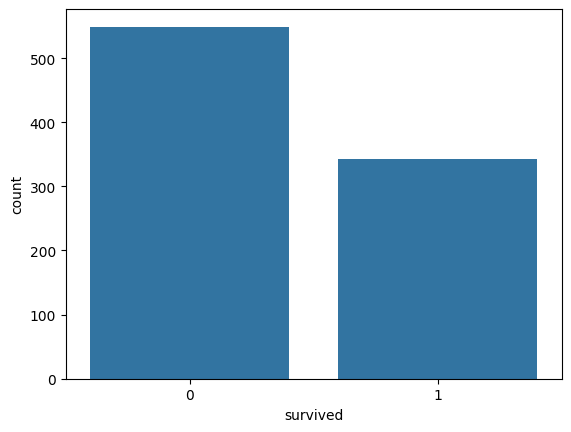

In [17]:
sns.countplot(df, x="survived")

<Axes: xlabel='embarked', ylabel='count'>

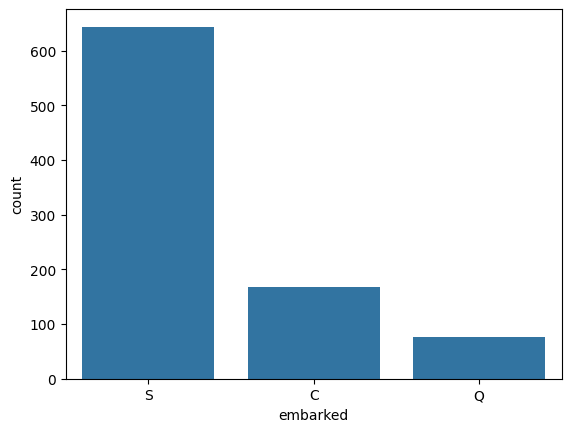

In [19]:
sns.countplot(df, x="embarked")

2. **Pie Chart**
We can also use pie charts to visualize the distribution of categorical data. 

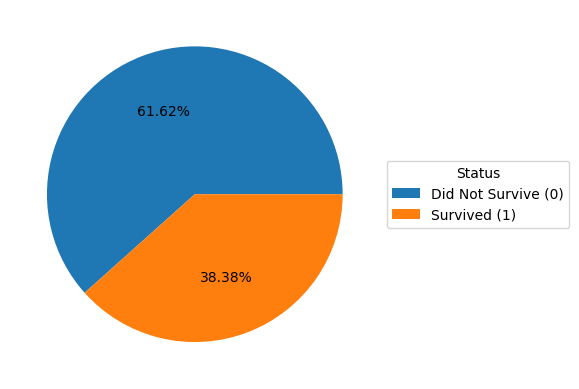

In [21]:
import matplotlib.pyplot as plt
df["survived"].value_counts().plot(kind="pie", autopct="%.2f%%", labels=["", ""])
plt.legend(
    title = "Status",
    labels=["Did Not Survive (0)", "Survived (1)"],
    bbox_to_anchor=(1, 0.5),
    loc="center left",
)
plt.ylabel("") 

plt.show()

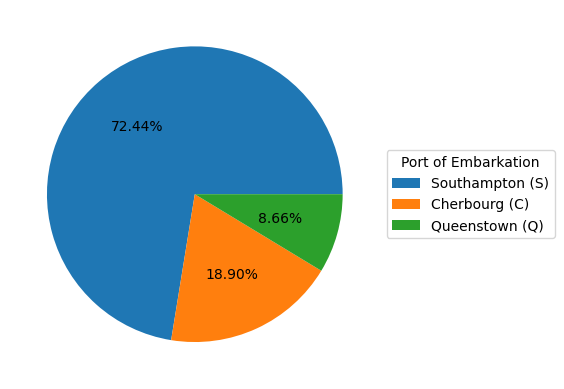

In [22]:
df["embarked"].value_counts().plot(kind="pie", autopct="%.2f%%", labels=["", "", ""])
plt.legend(
    title = "Port of Embarkation",
    labels=["Southampton (S)", "Cherbourg (C)", "Queenstown (Q)"],
    bbox_to_anchor=(1, 0.5),
    loc="center left",
)
plt.ylabel("")
plt.show()

### For Numerical Data

1. **Histogram**
We use histograms to visualize the distribution of numerical data. 

(array([100., 346., 188.,  69.,  11.]),
 array([ 0.42 , 16.336, 32.252, 48.168, 64.084, 80.   ]),
 <BarContainer object of 5 artists>)

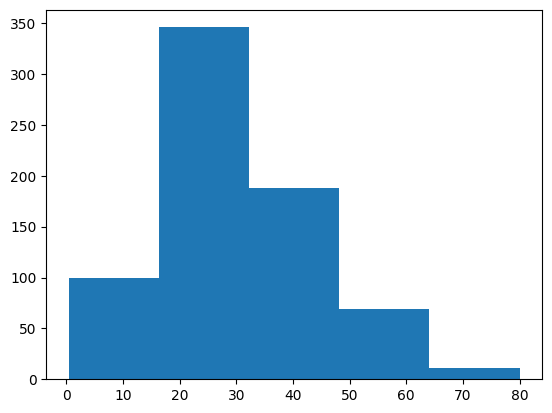

In [24]:
plt.hist(df['age'],bins=5)

2. **Distribution Plot**
We can also use distribution plots to visualize the distribution of numerical data. 

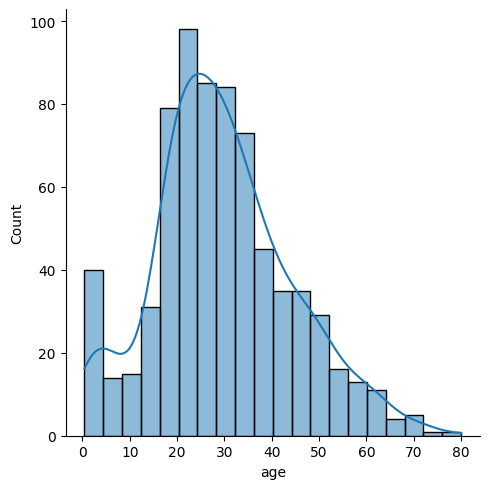

In [25]:
sns.displot(data=df, x="age", kde = True)

3. **Box Plot**
We use box plots to visualize the distribution of numerical data and identify outliers. 

<Axes: xlabel='age'>

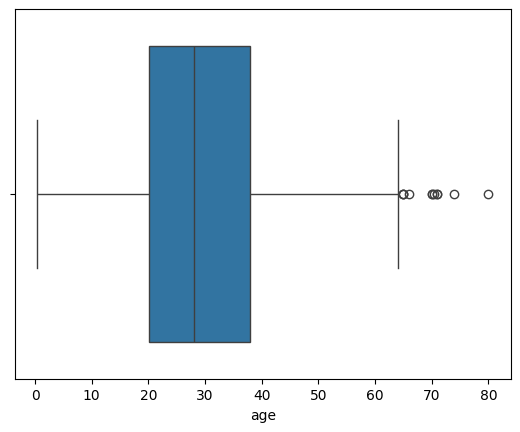

In [26]:
sns.boxplot(data=df, x="age")

Here are some functions that are also necessary for Univariate EDA:

In [27]:
df['age'].min()

np.float64(0.42)

In [28]:
df['age'].max()

np.float64(80.0)

In [29]:
df['age'].mean()

np.float64(29.69911764705882)

In [30]:
df['age'].skew()

np.float64(0.38910778230082704)